# Helmholtz & Anti-Helmholtz Coil Simulation
Documentation: https://docs.google.com/presentation/d/1INlCZmiFLztyq61BgA-tvESFtgUuOYCLFEUQNp9QsF8/edit?usp=drive_link

# About
The following script generates a FEMM model, solves it, conducts additional calculations, and extracts data for axisymmetric magnetostatic problems.

# Prerequisites
- Python 3.9 (https://www.python.org/downloads/release/python-390/). I suggest the Miniconda version (https://docs.conda.io/projects/miniconda/en/latest/miniconda-other-installer-links.html.
- Jupyter Notebooks

# Setup
1. Download FEMM (https://www.femm.info/wiki/HomePage)
2. pip install pyfemm
* If you have MacOS or Linux refer to the manual (https://www.femm.info/wiki/pyFEMM/manual.pdf)

# Resources
- FEMM Official Documentation (https://www.femm.info/wiki/Documentation/)

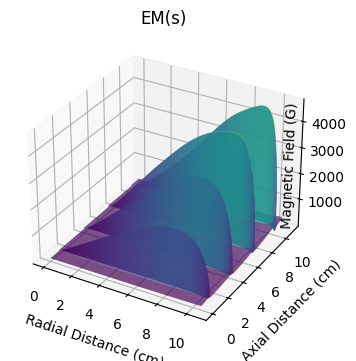

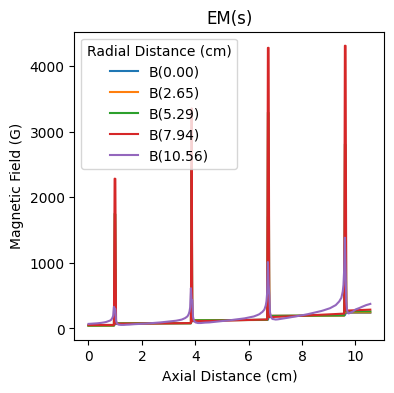

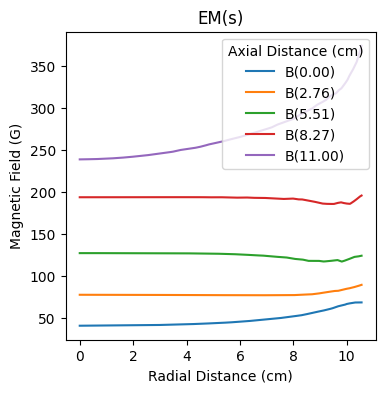

Current: 3.6 A
Wire Gage: 18 AWG
Number of Turns: 1152
Wire Length/Coil: 940.97 cm
EM Thickness: 3 cm
EM Inner Radius: 11.00 cm
EM Outer Radius: 15.00 cm
EM seperation: 11.00 cm
Electrode Radius: 10.56 cm
Electrode Area: 350.00 cm^2
Maximum Radial Gradient is 1.29e+01 G/cm at (9.97, 0.00)
Maximum Axial Gradient is 1.24e+03 G/cm at (0.00, 7.03)
Resistance/Coil: 19.27 ohms.
Power Loss/Coil: 249.79 watts.
Voltage Requirement/Coil: 69.39 volts
Wire heats 329.92C in 3600 seconds


'\nclose\n'

In [1]:
""" 
Kostubh Agarwal
kagarwal@formenergy.com
"""
import femm
import matplotlib.pyplot as plt
import numpy as np

"""
wire specs
- https://mwswire.com/wp-content/uploads/2016/10/Copper-Magnet-Wire-Data.pdf
"""
wire_d = 1.034 #18 AWG, NEMA MW-16C, diameter (mm)
wire_c = 0.385 #specific heat (J/gC)
wire_p = 1.72e-8 #resistivity (ohm-m)
wire_ds = 8.96 #density (g/cm^3)

"""
coil specs
"""
coil_off = 4 #ID/OD offset (cm)
coil_l = 3 #coil thickness (cm)
coil_ri = 11 #coil internal radius (cm)
coil_ro = coil_ri + coil_off #coil outer radius (cm)
coil_n = 1152 #number of turns

"""
electrode specs
"""
elec_a = 350 #area of WE (cm^2)
elec_r = np.sqrt(elec_a / np.pi) #electrode radius, assuming circular electrodes, also defines plotted area (cm)
elec_t = 0.05 #electrode thickness (cm)
elec_d = 1 #distance from EM (cm)

"""
particle specs (optional)
"""
par_r = 0.01 #particle radius (cm)
par_d = 0.5 #distance from surface of magnet
par_z = coil_l / 2 + par_d #particle position (cm)

"""
data analysis
"""
num = 400 #number of datapoints pulled from simulation, 400 is suggested, for code development 50 is sufficient
num_int = 5 #number of intervals for the 2D plots for axial and radial distances in graphs
intervals = np.arange(5) * int(num / (num_int - 1))
intervals[-1] = num - 1
# intervals = [0] #if you just want to plot a singular axial and radial distance

"""
simulation paramaters
"""
precision = 1e-8 #solver precision
label_tol = 1e-2 #label offset, places label inside shape
bound_r = 2 * coil_ro #boundary radius (cm)
i = 3.6 #current (A)

"""
initialization
"""
femm.openfemm();
femm.newdocument(0)

"""
problem definition

magnetostatic; units of measure; axisymmetric; 
precision for the linear solver; a placeholder for 
the depth dimension; angle constraint of 30 degrees;
"""
femm.mi_probdef(0, 'centimeters', 'axi', precision, 0, 30); 

"""
setup - materials
"""
#air
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0); #air
femm.mi_addblocklabel(coil_ro+label_tol, label_tol);
femm.mi_selectlabel(coil_ro+label_tol, label_tol);
femm.mi_setblockprop('Air', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

#iron -- data is from FEMM material library, but for some reason the script does not find material properties automatically
femm.mi_addmaterial('Iron', 14872, 14872, 0, 0, 0, 1, 0, 0, 0, 0, 0);
bdata = [0.000000, 0.227065, 0.454130, 0.681195, 0.908260, 1.135330, 1.362390, 1.589350, 1.812360, 2.010040, 2.133160, 2.199990, 2.254790, 2.299930, 2.342510, 2.378760, 2.415010, 2.451260, 2.487500, 2.523750, 2.560000]
hdata = [0.000000, 13.898400, 27.796700, 42.397400, 61.415700, 82.382400, 144.669000, 897.760000, 4581.740000, 17736.200000, 41339.300000, 68321.800000, 95685.500000, 123355.000000, 151083.000000, 178954.000000, 206825.000000, 234696.000000, 262568.000000, 290439.000000, 318310.000000]
for idx in range(len(bdata)):
    femm.mi_addbhpoint('Iron', bdata[idx], hdata[idx])
    
#pure annealed nickel -- data is from FEMM material library, but for some reason the script does not find material properties automatically
femm.mi_addmaterial('Pure nickel annealed')
bdata = [0.000000, 0.056855, 0.070679, 0.088178, 0.090246, 0.092263, 0.224499, 0.257443, 0.266530, 0.288314, 0.333679, 0.352664, 0.404646, 0.410247, 0.433867, 0.470015, 0.490399, 0.494892, 0.508558, 0.546380, 0.586685, 0.590509, 0.603583, 0.613213, 0.625268, 0.632070, 0.643027, 0.682933,
0.694518, 0.737378, 0.767764, 0.883664, 0.981222, 1.009461]
hdata = [0.000000, 63.557963, 69.056222, 75.810815, 76.600889, 77.399185, 141.192593, 166.668519, 175.539259, 205.092222, 301.095185, 366.736296, 850.455185, 943.526667, 1687.981481, 3180.525926, 4166.196296, 4434.014815, 5127.622222, 7767.114815, 13328.370370, 14185.407407, 17460.481481,
19984.296296, 26455.962963, 29658.814815, 36131.629630, 63324.185185, 72483.592593, 104274.074074, 128363.703704, 220358.148148, 297860.370370, 320300.000000]
for idx in range(len(bdata)):
    femm.mi_addbhpoint('Pure nickel annealed', bdata[idx], hdata[idx])  

"""
setup - physical
"""
sep = 11 #distance of em's (cm)

# #core (top)  
# femm.mi_drawrectangle(0, sep/2, coil_ri, sep/2+coil_l);
# femm.mi_addblocklabel(label_tol, sep/2+label_tol);
# femm.mi_selectlabel(label_tol, sep+label_tol);
# femm.mi_setblockprop('Iron', 1, 0, '<None>', 0, 0, 0);
# femm.mi_clearselected()

# #coil (top)
# femm.mi_drawrectangle(coil_ri, sep/2+4, coil_ro, sep/2+coil_l+4); 
# femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239);
# femm.mi_addblocklabel(coil_ri+label_tol, sep/2+label_tol+4);
# femm.mi_selectlabel(coil_ri+label_tol, sep/2+label_tol+4);
#femm.mi_addcircprop('icoil', i, 1); #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
# femm.mi_setblockprop('Coil', 1, 0, 'icoil', 0, 0, coil_n);
# femm.mi_clearselected()

#coil (top)
femm.mi_drawrectangle(coil_ri, sep/2, coil_ro, sep/2+coil_l); 
femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239);
femm.mi_addblocklabel(coil_ri+label_tol, sep/2+label_tol);
femm.mi_selectlabel(coil_ri+label_tol, sep/2+label_tol);
femm.mi_addcircprop('icoil', i, 1); #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
femm.mi_setblockprop('Coil', 1, 0, 'icoil', 0, 0, coil_n);
femm.mi_clearselected()

# #core (bottom)
# femm.mi_drawrectangle(0, -sep/2, coil_ri, -sep/2-coil_l);  
# femm.mi_addblocklabel(label_tol, -sep/2-label_tol);
# femm.mi_selectlabel(label_tol, -sep/2-label_tol);
# femm.mi_setblockprop('Iron', 1, 0, '<None>', 0, 0, 0);
# femm.mi_clearselected()

#coil (bottom)
femm.mi_drawrectangle(coil_ri, -sep/2, coil_ro, -sep/2-coil_l);
femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239);
femm.mi_addblocklabel(coil_ri+label_tol, -sep/2-label_tol);
femm.mi_selectlabel(coil_ri+label_tol, -sep/2-label_tol);
femm.mi_addcircprop('icoil', -i, 1); #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
femm.mi_setblockprop('Coil', 1, 0, 'ocoil', 0, 0, coil_n);
femm.mi_clearselected()

# #coil (bottom)
# femm.mi_drawrectangle(coil_ri, -sep/2-4, coil_ro, -sep/2-coil_l-4);
# femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239);
# femm.mi_addblocklabel(coil_ri+label_tol, -sep/2-label_tol-4);
# femm.mi_selectlabel(coil_ri+label_tol, -sep/2-label_tol-4);
#femm.mi_addcircprop('icoil', i, 1); #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
# femm.mi_setblockprop('Coil', 1, 0, 'ocoil', 0, 0, coil_n);
# femm.mi_clearselected()

#electrodes (WEs)
femm.mi_drawrectangle(0, elec_d-sep/2, elec_r, elec_d+elec_t-sep/2); 
femm.mi_addblocklabel(label_tol, elec_d+elec_t/2-sep/2);
femm.mi_selectlabel(label_tol, elec_d+elec_t/2-sep/2);
femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

femm.mi_drawrectangle(0, elec_d-sep/2+3, elec_r, elec_d+elec_t-sep/2+3); 
femm.mi_addblocklabel(label_tol, elec_d+elec_t/2-sep/2+3);
femm.mi_selectlabel(label_tol, elec_d+elec_t/2-sep/2+3);
femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

femm.mi_drawrectangle(0, elec_d-sep/2+6, elec_r, elec_d+elec_t-sep/2+6); 
femm.mi_addblocklabel(label_tol, elec_d+elec_t/2-sep/2+6);
femm.mi_selectlabel(label_tol, elec_d+elec_t/2-sep/2+6);
femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

femm.mi_drawrectangle(0, elec_d-sep/2+9, elec_r, elec_d+elec_t-sep/2+9); 
femm.mi_addblocklabel(label_tol, elec_d+elec_t/2-sep/2+9);
femm.mi_selectlabel(label_tol, elec_d+elec_t/2-sep/2+9);
femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

# #feedstock particle (iron)
# femm.mi_drawrectangle(0, - par_r + par_z - sep, par_r, par_r + par_z - sep); #particle
# femm.mi_addblocklabel(par_r / 2, par_r + par_z - sep - label_tol);
# femm.mi_selectlabel(par_r / 2, par_r + par_z - sep - label_tol);
# femm.mi_setblockprop('Iron', 1, 0, '<None>', 0, 2, 0);
# femm.mi_clearselected()

"""
dirichlet BC (IABC)
"""
femm.mi_makeABC(7, bound_r, 0, 0, 0) #Defines and Improvised Asymptotic Boundary Condition)
    
"""
save file
"""
femm.mi_zoomnatural()
femm.mi_saveas('electro_mag_sim.fem');

"""
mesh and solve
"""
femm.mi_analyze()
femm.mi_loadsolution()

"""
force
"""
# femm.mo_groupselectblock(2)
# par_force=femm.mo_blockintegral(19)

"""
efficiency calculations
"""
wire_length = coil_n * np.pi * (coil_ri + coil_ro) * 1e-2 #length of wire (m)
wire_r = wire_d * 1e-3 / 2 #wire radius (m)
wire_area = wire_r ** 2 * np.pi #wire cross-sectional area (m^2)
resistance = wire_p * wire_length / wire_area #resistance (ohm)
wire_m = wire_length * wire_area * 1e6 * wire_ds #mass of wire (g)
power = i ** 2 * resistance #power loss (W)
voltage = i * resistance #voltage required (V)

"""
heat generation
"""
t_s = 3600  # Time (s)
dT = power * t_s / (wire_m * wire_c) #delta Temp (C)

"""
initilizalize arrays & load data
"""
r = np.linspace(0, elec_r, num) #initiliazing domain
z = np.linspace(0, sep, num) #initializing range
B = np.zeros((num, num)) #initilizing flux array

for a in range(0, num):
    for b in range(0, num):
        s, t = femm.mo_getb(r[a], z[b] -  sep/2)
        B[a, b] = (np.sqrt(s ** 2 + t ** 2)) / 1e-4 #tesla --> gauss

"""
max gradient calcs
"""
loc_r = 0 #defines radial position
loc_z = 0 #defines axial position

fr = B[:, loc_z] #defines radial domain 
fz = B[loc_r, :] #defines axial range

dr = np.abs(np.diff(fr)) #calculate the magnitude of gradients
m_dr = np.max(dr) * (num / elec_r) #max gradient w/ conversion back to gauss/cm
m_dr_i = np.argmax(dr) + 1 #index location of max gradient

dz = np.abs(np.diff(fz)) #calculate the magnitude of gradients 
m_dz = np.max(dz) * (num / sep) #max gradient w/ conversion back to gauss/cm
m_dz_i = np.argmax(dz) + 1 #index location of max gradient

"""
plots
"""
# 3D field plot
ax = plt.figure(figsize=(4,4)).add_subplot(111, projection='3d') #3d plot
Z, R = np.meshgrid(z, r)
ax.plot_surface(R, Z, B, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
ax.set_title('EM(s)')
ax.set_xlabel("Radial Distance (cm)")
ax.set_ylabel("Axial Distance (cm)")
ax.set_zlabel("Magnetic Field (G)")
ax.zaxis.labelpad = -26

# axial field plot
plt.figure(figsize=(4,4))  
for ir in intervals:
    r_data = r  
    z_data = B[ir, :]
    label = f'B({r[ir]:.2f})'
    plt.plot(r_data, z_data, label=label)
plt.xlabel('Axial Distance (cm)')
plt.ylabel('Magnetic Field (G)')
plt.title('EM(s)')
legend = plt.legend()
legend.set_title('Radial Distance (cm)')
plt.show()

# radial field plot
plt.figure(figsize=(4,4)) 
for iz in intervals:
    r_data = r
    z_data = B[:, iz]
    label = f'B({z[iz]:.2f})'
    plt.plot(r_data, z_data, label=label)
plt.xlabel('Radial Distance (cm)')
plt.ylabel('Magnetic Field (G)')
plt.title('EM(s)')
legend = plt.legend()
legend.set_title('Axial Distance (cm)')
plt.show()

"""
output
"""
print(f"Current: {i} A")
print(f"Wire Gage: 18 AWG")
print(f"Number of Turns: {coil_n}")
print(f"Wire Length/Coil: {wire_length:.2f} cm")
print(f"EM Thickness: {coil_l} cm")
print(f"EM Inner Radius: {coil_ri:.2f} cm")
print(f"EM Outer Radius: {coil_ro:.2f} cm")
print(f"EM seperation: {sep:.2f} cm")
print(f"Electrode Radius: {elec_r:.2f} cm")
print(f"Electrode Area: {elec_a:.2f} cm^2")
print(f"Maximum Radial Gradient is {m_dr:.2e} G/cm at ({r[m_dr_i]:.2f}, {z[loc_z]:.2f})")
print(f"Maximum Axial Gradient is {m_dz:.2e} G/cm at ({r[loc_r]:.2f}, {z[m_dz_i]:.2f})")
# print(f"Force on particle (cylinder w/ radius & height: {par_r:.2e}) at {par_d:.2f} cm away: {par_force:.2e} N")
print(f"Resistance/Coil: {resistance:.2f} ohms.")
print(f"Power Loss/Coil: {power:.2f} watts.")
print(f"Voltage Requirement/Coil: {voltage:.2f} volts")
print(f"Wire heats {dT:.2f}C in {t_s} seconds")

"""
close
"""
# femm.closefemm()